# BIO-322 Miniproject  
### Neural Activity-Based Trial Type Prediction  
**Authors:** Tuline Dachraoui (361774) & Sasha Ghanipour (364009)
**Date:** Fall 2025

---

## Introduction

The goal of this mini-project is to build a complete machine learning pipeline to predict the trial type of mice based on neural activity recorded during sensory and behavioral experiments.

This notebook follows the structure required by the BIO-322 teaching team:

1. Data Inspection  
2. Preprocessing  
3. Linear Model (baseline)  
4. Non-Linear Models  
5. Summary & Conclusions  

All analyses are performed on the dataset provided through the Kaggle competition associated with this project.


In [1]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Models (example: Linear & Non-linear)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# System
import os
import random

# Reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)


# 1. Data Inspection

In this section, we load the training and test datasets, explore their structure, visualize distributions, check for missing values, and get an initial intuition of the problem.

Understanding the dataset is crucial before any preprocessing or modeling.


In [3]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

train_df.head()


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29,TRIAL_TYPE
0,PG082_20221113,0,0.388889,0.444444,0.166667,0.222222,0.333333,0.000000,0.333333,0.166667,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W+ nolick
1,PG082_20221113,1,0.444444,0.222222,0.388889,0.277778,0.111111,0.055556,0.333333,0.166667,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GO W+ lick
2,PG082_20221113,2,0.055556,0.166667,0.333333,0.111111,0.166667,0.166667,0.111111,0.222222,...,0.0,1.0,0.5,0.5,1.0,1.0,0.0,0.5,0.0,GO W- lick
3,PG082_20221113,3,0.277778,0.555556,0.388889,0.444444,0.500000,0.333333,0.222222,0.277778,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W- nolick
4,PG082_20221113,4,0.277778,0.222222,0.111111,0.166667,0.277778,0.388889,0.333333,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no tone W+ lick


In [4]:
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

train_df.info()


Training set shape: (4407, 1383)
Test set shape: (2292, 1382)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Columns: 1383 entries, session_id to TRIAL_TYPE
dtypes: float64(1380), int64(1), object(2)
memory usage: 46.5+ MB


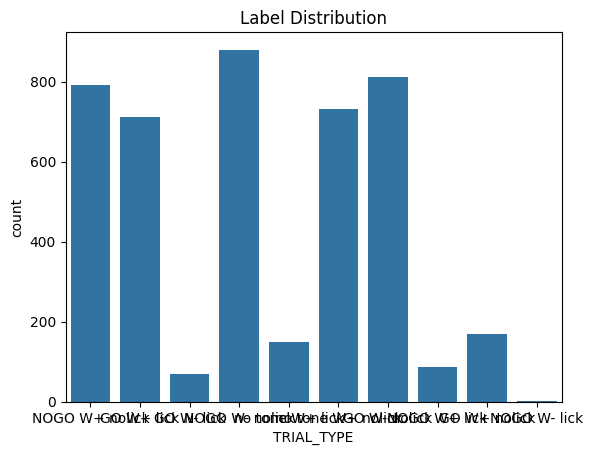

TRIAL_TYPE
NOGO W- nolick       0.199682
GO W- nolick         0.184479
NOGO W+ nolick       0.179941
no tone W+ nolick    0.165872
GO W+ lick           0.161334
GO W+ nolick         0.038348
no tone W+ lick      0.034037
NOGO W+ lick         0.019968
GO W- lick           0.015657
NOGO W- lick         0.000681
Name: proportion, dtype: float64

In [6]:
# Distribution of target classes
# dataset uses 'TRIAL_TYPE' as the target column
sns.countplot(x=train_df['TRIAL_TYPE'])
plt.title("Label Distribution")
plt.show()

train_df['TRIAL_TYPE'].value_counts(normalize=True)
